In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("smartcart_customers.csv")

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [6]:
df.shape

(2240, 22)

In [9]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Data Preprocessing

# handle missing values

In [8]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [13]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering

In [33]:
#Age
df["Age"] = 2026-df["Year_Birth"]

In [17]:
# calculate customer tenure days or customer joining date

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["customer_tenure_days"] = (reference_date - df["Dt_Customer"]).dt.days

In [34]:
#Spending
df["total_spending"] = df["MntWines"] +df["MntFruits"] +df["MntMeatProducts"] +df["MntFishProducts"] +df["MntSweetProducts"] +df["MntGoldProds"]

In [35]:
#Total children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [32]:
#Education
df["Education"].value_counts()# to view this data use this

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate","PhD":"Postgraduate"  
})

In [81]:
# marital status
df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Partner":"Alone","Divorced":"Alone","Widow":"Alone",
    "Absurd":"Alone","YOLO":"Alone","Single":"Alone"
})


In [86]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# DROP COLUMNS

In [91]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]

Spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + Spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [92]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

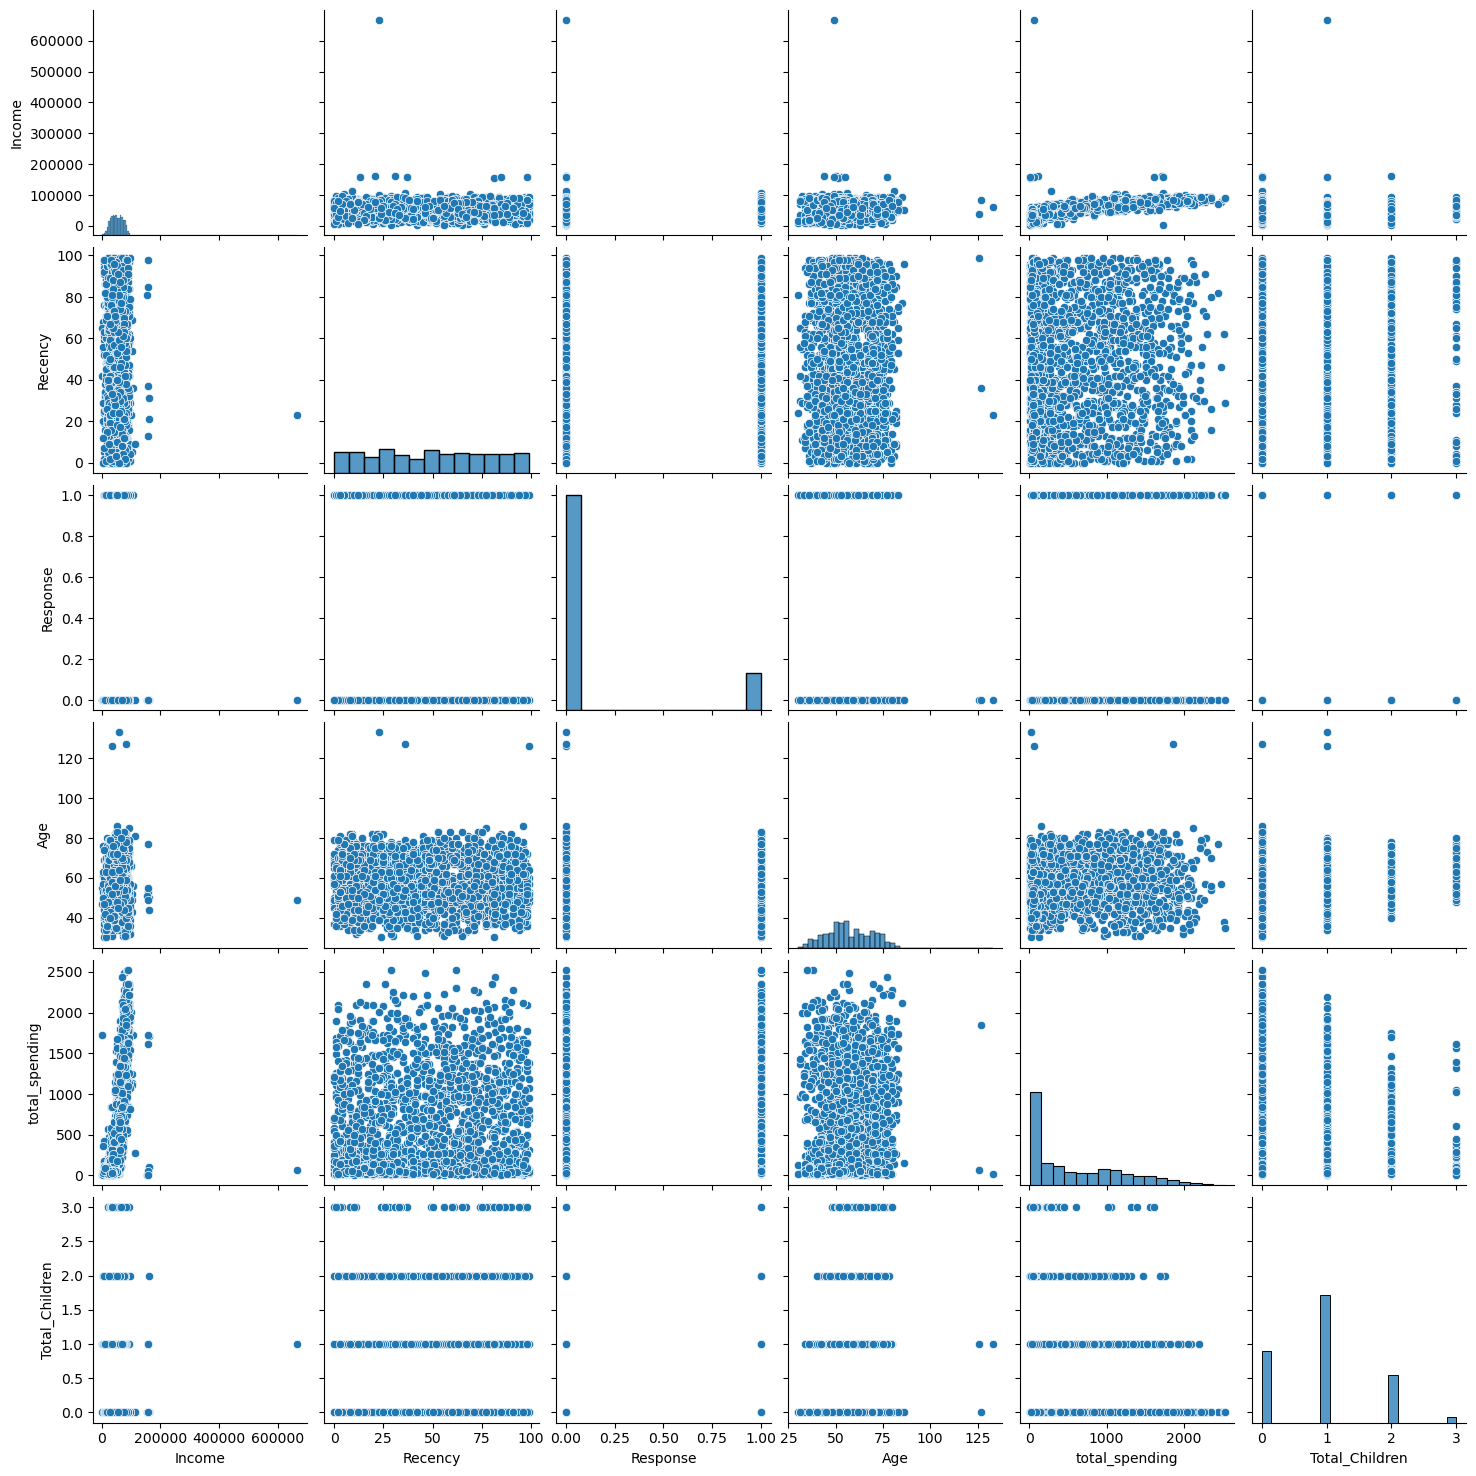

In [93]:
cols = ["Income","Recency","Response","Age","total_spending","Total_Children"]

#relative plot for some features - pairplot

sns.pairplot(df_cleaned[cols])

In [94]:
# Remove Outliers

print("data size with outliers", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"]<90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"]<600_000) ]

print("data size without outliers", len(df_cleaned))

data size with outliers 2240
data size without outliers 2236


# Heatmap

In [95]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

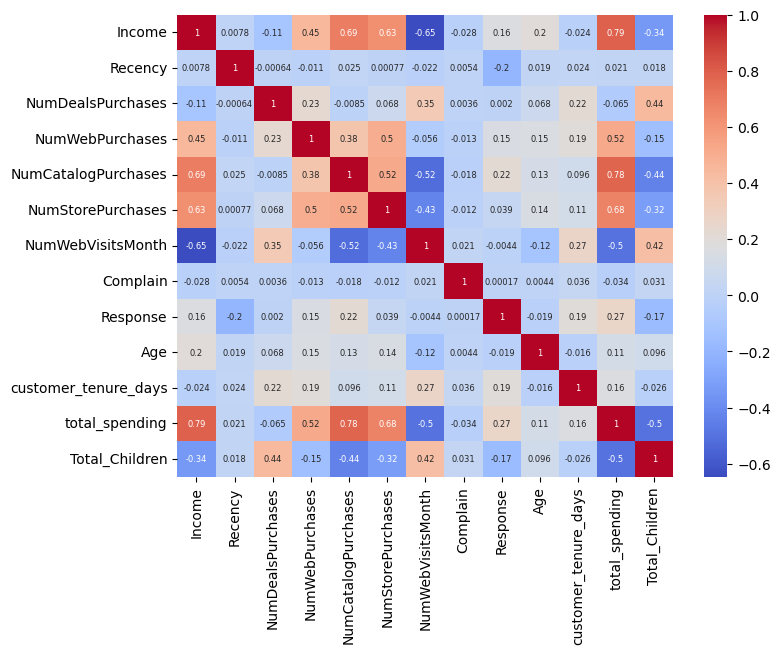

In [96]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

# Encoding

In [97]:
from sklearn.preprocessing import OneHotEncoder

In [98]:
ohe = OneHotEncoder()
cat_cols = ["Education","Living_With"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])


enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [102]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [103]:
df_encoded.shape

(2236, 18)

In [104]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [105]:
from sklearn.preprocessing import StandardScaler

In [106]:
X = df_encoded

In [108]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# visualizing

In [114]:
X_scaled.shape

(2236, 18)

In [115]:
# 2D

from sklearn.decomposition import PCA

In [120]:
pca =PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)


In [121]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

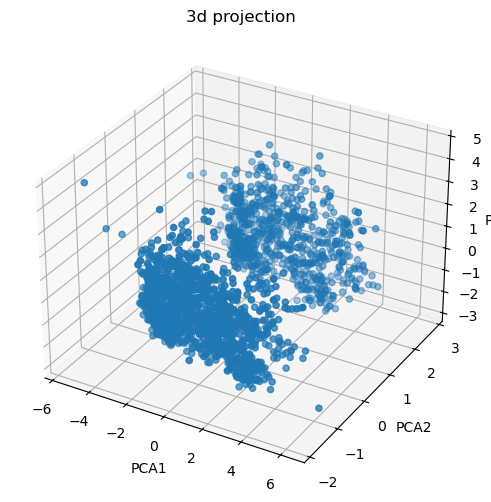

In [125]:
# plot

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")


ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Analyze K value
# 1.Elbow method

In [128]:
!pip install kneed


In [131]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [132]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optinal_k= knee.elbow

In [133]:
print("best k :",optinal_k)

best k : 4


Text(0, 0.5, 'WCSS')

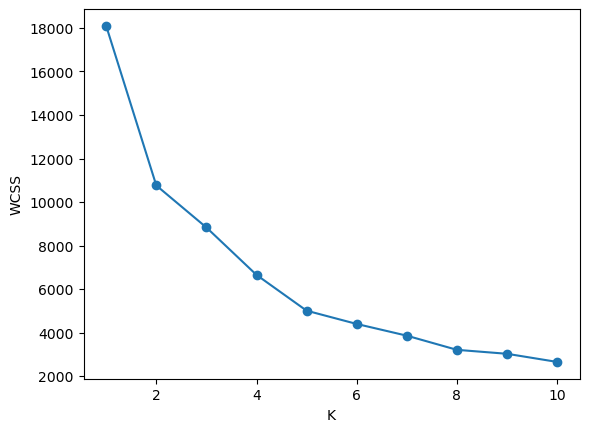

In [134]:
# plot

plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")

# Silhouette Score

Text(0, 0.5, 'silhouette_score')

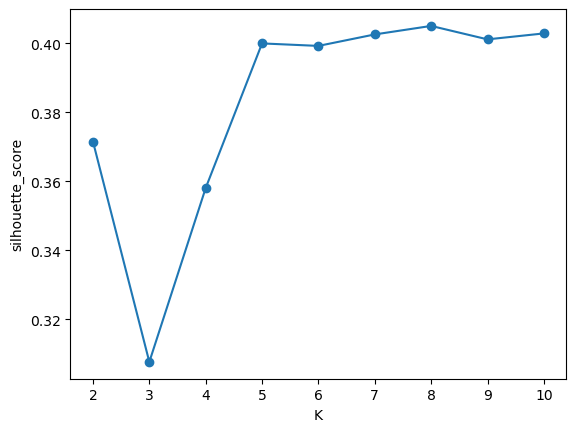

In [135]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

#plot

plt.plot(range(2,11),scores,marker="o")
plt.xlabel("K")
plt.ylabel("silhouette_score")

Text(0, 0.5, 'SS')

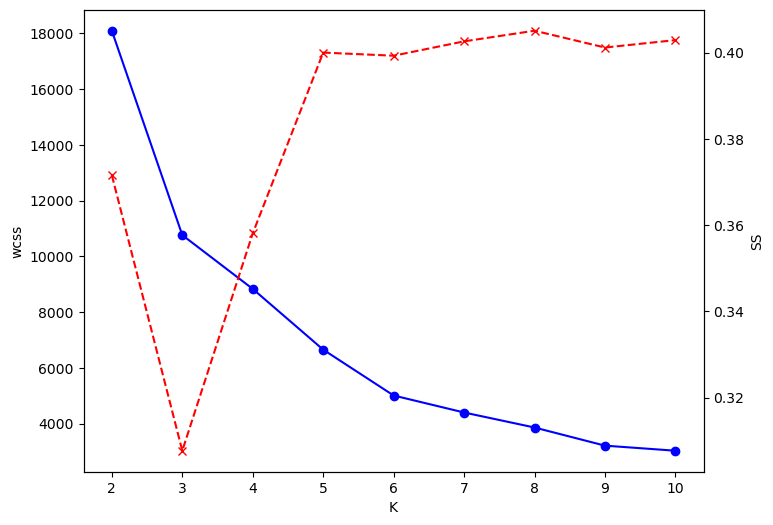

In [141]:
# combined plot

k_range = range(2,11)

fig,ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("SS")

# Clustering 

In [142]:
# k-means

kmeans = KMeans(n_clusters=4)
labels_kmeans = kmeans.fit_predict(X_pca)



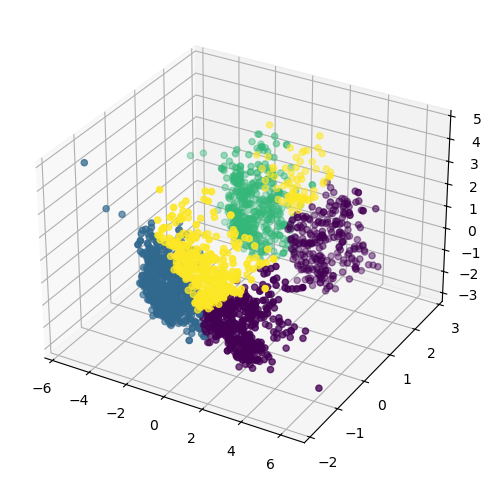

In [143]:
# 3D

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")


ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

# ax.set_xlabel("PCA1")
# ax.set_ylabel("PCA2")
# ax.set_zlabel("PCA3")
# ax.set_title("3d projection")

In [145]:
# Agglomerative clustering

from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)


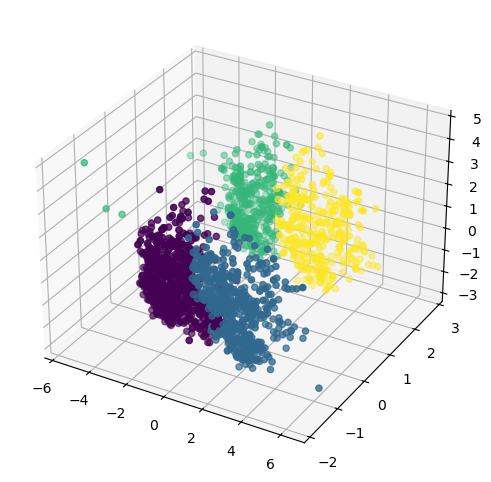

In [146]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")


ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

# Characterization of clustering

In [156]:
# df_cleaned.drop("labels",axis=1)
X["cluster"]=labels_agg


In [157]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,Total_Children,Living_With,labels,cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0,0


<Axes: xlabel='cluster', ylabel='count'>

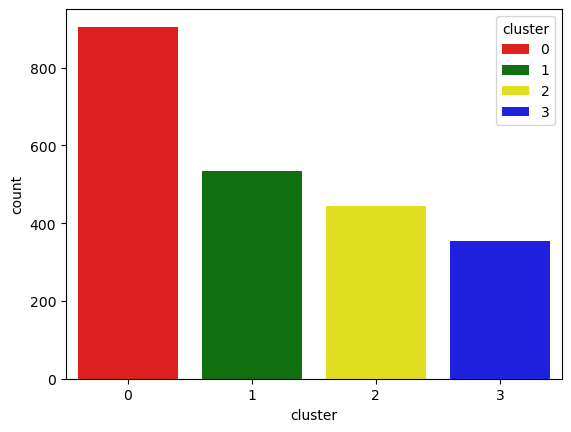

In [158]:
pal = ["red","green","yellow","blue"]

sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

<Axes: xlabel='total_spending', ylabel='Income'>

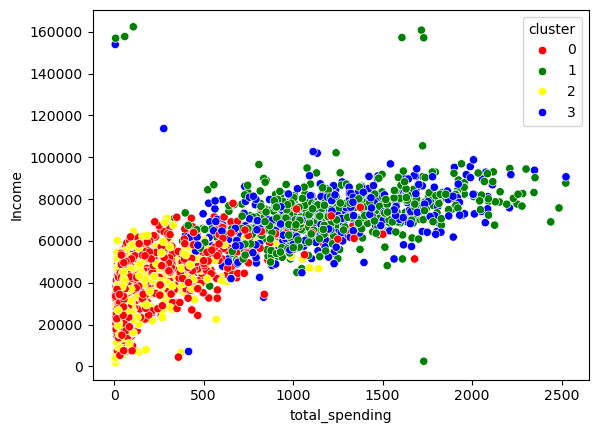

In [159]:
# income & spending patterns

sns.scatterplot(x=X["total_spending"],y=X["Income"],hue=X["cluster"],palette=pal)

In [160]:
# Clustering summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  customer_tenure_days  total_spending  \
cluster         